=== RUNNING BASELINE (CONTROLLERS OFF) ===
Iteration 100: TNOW = 489.00
Iteration 200: TNOW = 980.00
Baseline Execution Time: 0.4498 seconds.
Baseline Total Throughput: 6,142.49 t/day



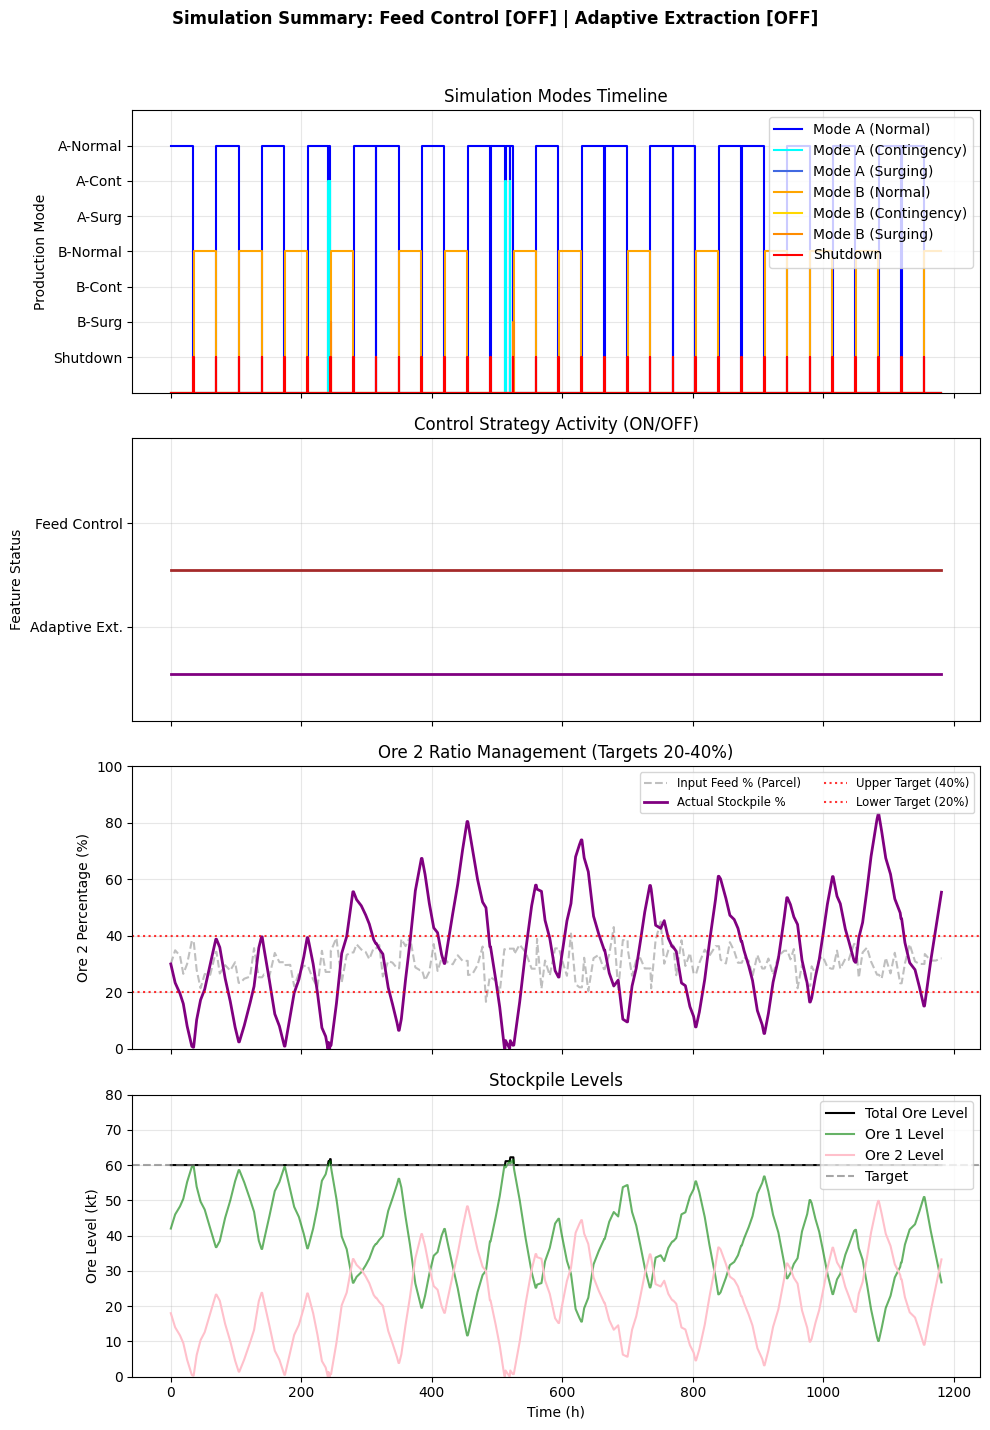

=== RUNNING SMART SYSTEM (CONTROLLERS ON) ===
Iteration 100: TNOW = 524.00
Iteration 200: TNOW = 1037.67
Smart Execution Time: 0.4348 seconds.
Smart Total Throughput: 6,081.58 t/day



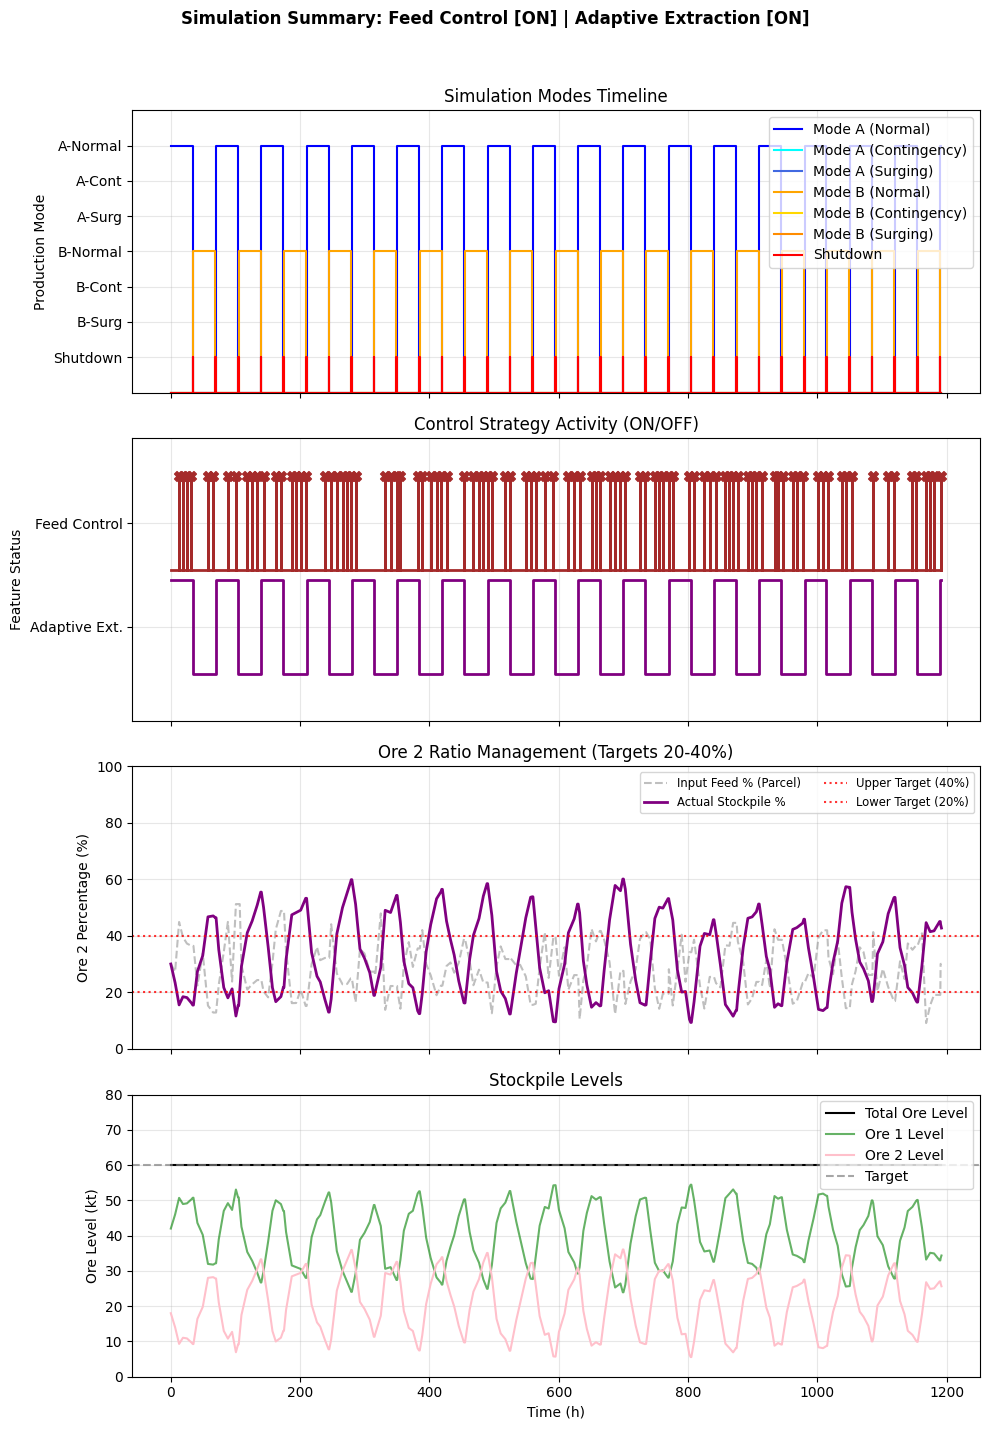

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
import time

from model.drs_model import DRSModel


@dataclass
class MiningParameters:
    parameter_OreToBeExtractedDuringWarmingPeriod: float = 600000.0
    parameter_TotalOreToBeExtracted: float = 6600000.0
    parameter_DurationOfProductionCampaigns: float = 34.0
    parameter_DurationOfShutdowns: float = 1.0
    parameter_ModeAOre1MillingRate: float = 3600.0
    parameter_ModeAOre2MillingRate: float = 2400.0
    parameter_ModeAContingencyOre1MillingRate: float = 3900.0
    parameter_ModeBOre1MillingRate: float = 4600.0
    parameter_ModeBOre2MillingRate: float = 800.0
    parameter_ModeBContingencyOre2MillingRate: float = 2500.0
    parameterVector_GeostatisticalModelParameters: tuple = (
        30000.0,
        50000.0,
        30.0,
        30.0,
        5.0,
        1.0,
    )
    controlVariable_CriticalOre2Level: float = 20400.0
    controlVariable_TargetOreStockLevel: float = 60000.0
    controlVariable_DurationOfContingencySegments: float = 1.0

    # Adaptive Extraction Limits
    parameter_MaxExtraction: float = 7200.0
    parameter_MinExtraction: float = 5000.0

    # Dynamic Toggles
    parameter_ExtractionGain: float = 0.0
    enable_feed_control: bool = False
    controlVariable_StockUpperLimit: float = 60000.0
    controlVariable_StockLowerLimit: float = 60000.0


def generate_arena_config():
    # 1. Total mill rates for normal modes
    total_mill_A = "(parameter_ModeAOre1MillingRate + parameter_ModeAOre2MillingRate)"
    total_mill_B = "(parameter_ModeBOre1MillingRate + parameter_ModeBOre2MillingRate)"

    # 2. Dynamic Adaptive Extraction variables (collapses to base rate when gain is 0)
    ext_A_norm = f"max(parameter_MinExtraction, min(parameter_MaxExtraction, {total_mill_A} + (controlVariable_TargetOreStockLevel - OreStock_Level) * parameter_ExtractionGain))"
    ext_A_cont = f"max(parameter_MinExtraction, min(parameter_MaxExtraction, parameter_ModeAContingencyOre1MillingRate + (controlVariable_TargetOreStockLevel - OreStock_Level) * parameter_ExtractionGain))"
    ext_B_norm = f"max(parameter_MinExtraction, min(parameter_MaxExtraction, {total_mill_B} + (controlVariable_TargetOreStockLevel - OreStock_Level) * parameter_ExtractionGain))"
    ext_B_cont = f"max(parameter_MinExtraction, min(parameter_MaxExtraction, parameter_ModeBContingencyOre2MillingRate + (controlVariable_TargetOreStockLevel - OreStock_Level) * parameter_ExtractionGain))"

    # 3. Your perfectly balanced configuration mapped to the dynamic variables
    config = {
        "confExString_TerminatingCondition": "(OreExtraction_Level >= parameter_TotalOreToBeExtracted) && (ABS(OreStock_Level - controlVariable_TargetOreStockLevel)<0.001)",
        "confExString_InitialRateConfigurationNumber": "1",
        "confExString_InitialLevelValue": ["0", "0", "60000", "42000", "18000"],
        "confExString_InitialTimerValue": ["0"] * 9,
        "confExString_InitialDiscretelyDynamicalNumericalVariableValue": [
            "40000",
            "30",
            "1",
        ],
        "confExString_InitialCategoricalVariableValue": [""],
        "confExString_LevelRate": [
            # Level 0 (Extraction)
            [
                ext_A_norm,
                ext_A_cont,
                "parameter_ModeAOre1MillingRate*100/(100-PercentageOfOre2InCurrentParcel)",
                ext_B_norm,
                ext_B_cont,
                "parameter_ModeBOre2MillingRate*100/PercentageOfOre2InCurrentParcel",
                "0",
            ],
            # Level 1 (Parcel Progress)
            [
                ext_A_norm,
                ext_A_cont,
                "parameter_ModeAOre1MillingRate*100/(100-PercentageOfOre2InCurrentParcel)",
                ext_B_norm,
                ext_B_cont,
                "parameter_ModeBOre2MillingRate*100/PercentageOfOre2InCurrentParcel",
                "0",
            ],
            # Level 2 (Total Stockpile Level)
            [
                f"{ext_A_norm} - {total_mill_A}",
                f"{ext_A_cont} - parameter_ModeAContingencyOre1MillingRate",
                f"(parameter_ModeAOre1MillingRate*100/(100-PercentageOfOre2InCurrentParcel)) - {total_mill_A}",
                f"{ext_B_norm} - {total_mill_B}",
                f"{ext_B_cont} - parameter_ModeBContingencyOre2MillingRate",
                f"(parameter_ModeBOre2MillingRate*100/PercentageOfOre2InCurrentParcel) - {total_mill_B}",
                "0",
            ],
            # Level 3 (Ore 1 Level)
            [
                f"{ext_A_norm}*(1-PercentageOfOre2InCurrentParcel/100)-parameter_ModeAOre1MillingRate",
                f"{ext_A_cont}*(1-PercentageOfOre2InCurrentParcel/100)-parameter_ModeAContingencyOre1MillingRate",
                "0",
                f"{ext_B_norm}*(100-PercentageOfOre2InCurrentParcel)/100 - parameter_ModeBOre1MillingRate",
                f"{ext_B_cont}*(100-PercentageOfOre2InCurrentParcel)/100",
                "parameter_ModeBOre2MillingRate*(100-PercentageOfOre2InCurrentParcel)/(PercentageOfOre2InCurrentParcel)-parameter_ModeBOre1MillingRate",
                "0",
            ],
            # Level 4 (Ore 2 Level)
            [
                f"{ext_A_norm}*(PercentageOfOre2InCurrentParcel/100)-parameter_ModeAOre2MillingRate",
                f"{ext_A_cont}*(PercentageOfOre2InCurrentParcel/100)",
                "parameter_ModeAOre1MillingRate*PercentageOfOre2InCurrentParcel/(100-PercentageOfOre2InCurrentParcel)-parameter_ModeAOre2MillingRate",
                f"{ext_B_norm}*PercentageOfOre2InCurrentParcel/100 - parameter_ModeBOre2MillingRate",
                f"{ext_B_cont}*PercentageOfOre2InCurrentParcel/100 - parameter_ModeBContingencyOre2MillingRate",
                "0",
                "0",
            ],
        ],
        "confExString_LowerLevelThreshold": [
            ["-999999"] * 7,
            ["-999999"] * 7,
            [
                "-999999",
                "-999999",
                "controlVariable_StockLowerLimit",
                "-999999",
                "-999999",
                "controlVariable_StockLowerLimit",
                "-999999",
            ],
            ["0", "0", "-999999", "0", "-999999", "-999999", "-999999"],
            ["0", "-999999", "-999999", "0", "0", "-999999", "-999999"],
        ],
        "confExString_UpperLevelThreshold": [
            [
                "(OreExtraction_Level < parameter_OreToBeExtractedDuringWarmingPeriod)*parameter_OreToBeExtractedDuringWarmingPeriod + (OreExtraction_Level >= parameter_OreToBeExtractedDuringWarmingPeriod)*parameter_TotalOreToBeExtracted"
            ]
            * 7,
            ["MassOfCurrentParcel"] * 6 + ["999999"],
            ["controlVariable_StockUpperLimit"] * 7,
            ["999999"] * 7,
            ["999999"] * 7,
        ],
        "confExString_LowerLevelResultantRateConfiguration": [
            ["0"] * 7,
            ["0"] * 7,
            ["0", "0", "1", "0", "0", "4", "0"],
            ["3", "3", "0", "5", "0", "0", "0"],
            ["2", "0", "0", "6", "6", "0", "0"],
        ],
        "confExString_UpperLevelResultantRateConfiguration": [
            ["1", "2", "3", "4", "5", "6", "0"],
            ["1", "2", "3", "4", "5", "6", "0"],
            ["0"] * 7,
            ["0"] * 7,
            ["0"] * 7,
        ],
        "confExString_LowerLevelAssignmentAddress": [
            ["0"] * 7,
            ["0"] * 7,
            ["0"] * 7,
            ["0", "0", "0", "3", "0", "0", "0"],
            ["3", "0", "0", "0", "0", "0", "0"],
        ],
        "confExString_UpperLevelAssignmentAddress": [
            [
                "0 + 1*(OreExtraction_Level == parameter_OreToBeExtractedDuringWarmingPeriod)"
            ]
            * 6
            + ["0"],
            [
                "(NextParcelIsNewFacies==1)*(parameterVector_GeostatisticalModelParameters(5)<>0)*4 + (NextParcelIsNewFacies==1)*(parameterVector_GeostatisticalModelParameters(5)==0)*5 + (NextParcelIsNewFacies==0)*6"
            ]
            * 6
            + ["0"],
            ["0"] * 7,
            ["0"] * 7,
            ["0"] * 7,
        ],
        "confExString_TimerRate": [
            ["1"] * 7,
            ["0", "1", "0", "0", "1", "0", "0"],
            ["1", "0", "0", "0", "0", "0", "0"],
            ["0", "1", "0", "0", "0", "0", "0"],
            ["0", "0", "1", "0", "0", "0", "0"],
            ["0", "0", "0", "1", "0", "0", "0"],
            ["0", "0", "0", "0", "1", "0", "0"],
            ["0", "0", "0", "0", "0", "1", "0"],
            ["0", "0", "0", "0", "0", "0", "1"],
        ],
        "confExString_LowerTimerThreshold": [["-999999"] * 7 for _ in range(9)],
        "confExString_UpperTimerThreshold": [
            ["parameter_DurationOfProductionCampaigns"] * 6
            + ["parameter_DurationOfShutdowns"],
            [
                "999999",
                "controlVariable_DurationOfContingencySegments",
                "999999",
                "999999",
                "controlVariable_DurationOfContingencySegments",
                "999999",
                "999999",
            ],
            ["999999"] * 7,
            ["999999"] * 7,
            ["999999"] * 7,
            ["999999"] * 7,
            ["999999"] * 7,
            ["999999"] * 7,
            ["999999"] * 7,
        ],
        "confExString_LowerTimerResultantRateConfiguration": [
            ["0"] * 7 for _ in range(9)
        ],
        "confExString_UpperTimerResultantRateConfiguration": [
            [
                "7",
                "7",
                "7",
                "7",
                "7",
                "7",
                "(Ore2Stock_Level>controlVariable_CriticalOre2Level)*(OreStock_Level<=controlVariable_StockUpperLimit)*1+(Ore2Stock_Level>controlVariable_CriticalOre2Level)*(OreStock_Level>controlVariable_StockUpperLimit)*3+(Ore2Stock_Level<=controlVariable_CriticalOre2Level)*(OreStock_Level<=controlVariable_StockUpperLimit)*4+(Ore2Stock_Level<=controlVariable_CriticalOre2Level)*(OreStock_Level>controlVariable_StockUpperLimit)*6",
            ],
            ["0", "1", "0", "0", "4", "0", "0"],
            ["0"] * 7,
            ["0"] * 7,
            ["0"] * 7,
            ["0"] * 7,
            ["0"] * 7,
            ["0"] * 7,
            ["0"] * 7,
        ],
        "confExString_UpperTimerAssignmentAddress": [
            ["2"] * 7,
            ["0"] * 7,
            ["0"] * 7,
            ["0"] * 7,
            ["0"] * 7,
            ["0"] * 7,
            ["0"] * 7,
            ["0"] * 7,
            ["0"] * 7,
        ],
        "confExString_LowerTimerAssignmentAddress": [["0"] * 7 for _ in range(9)],
        "confExString_AssignmentSequence": [
            ["T003:0", "T004:0", "T005:0", "T006:0", "T007:0", "T008:0", "T009:0"],
            ["T001:0", "", "", "", "", "", ""],
            ["T002:0", "", "", "", "", "", ""],
            # Added E001:1 so the Feed Controller actually gets triggered when drawing parcels
            [
                "L002:0",
                "N001:UNIF(parameterVector_GeostatisticalModelParameters(1),parameterVector_GeostatisticalModelParameters(2))",
                "N002:MX(NORM(parameterVector_GeostatisticalModelParameters(4),parameterVector_GeostatisticalModelParameters(5)),0)",
                "N003:(UNIF(0,1)<= parameterVector_GeostatisticalModelParameters(3))",
                "E001:1",
                "",
                "",
            ],
            [
                "L002:0",
                "N001:UNIF(parameterVector_GeostatisticalModelParameters(1),parameterVector_GeostatisticalModelParameters(2))",
                "N002:parameterVector_GeostatisticalModelParameters(4)",
                "N003:(UNIF(0,1)<= parameterVector_GeostatisticalModelParameters(3))",
                "E001:1",
                "",
                "",
            ],
            [
                "L002:0",
                "N001:UNIF(parameterVector_GeostatisticalModelParameters(1),parameterVector_GeostatisticalModelParameters(2))",
                "N002:MX(PercentageOfOre2InCurrentParcel + parameterVector_GeostatisticalModelParameters(6)*UNIF(-1,1),0)",
                "N003:(UNIF(0,1)<= parameterVector_GeostatisticalModelParameters(3))",
                "E001:1",
                "",
                "",
            ],
        ],
    }
    return config


# ==========================================
# RUN 1: BASELINE (Controllers OFF)
# ==========================================
print("=== RUNNING BASELINE (CONTROLLERS OFF) ===")
params_baseline = MiningParameters()
params_baseline.parameter_ExtractionGain = 0.0
params_baseline.enable_feed_control = False
params_baseline.controlVariable_StockUpperLimit = 60000.0  # Hysteresis OFF
params_baseline.controlVariable_StockLowerLimit = 60000.0

baseline_model = DRSModel(parameters=params_baseline)
baseline_model.load_configuration(generate_arena_config())

start_time = time.time()
baseline_model.run()
print(f"Baseline Execution Time: {time.time() - start_time:.4f} seconds.")

stats_base = baseline_model.calculate_statistics()
print(f"Baseline Total Throughput: {stats_base.Throughput:,.2f} t/day\n")
baseline_model.plot_results()


# ==========================================
# RUN 2: SMART (Controllers ON)
# ==========================================
print("=== RUNNING SMART SYSTEM (CONTROLLERS ON) ===")
params_smart = MiningParameters()
params_smart.parameter_ExtractionGain = 0.08  # Adaptive Extraction ON
params_smart.enable_feed_control = True  # Feed Control ON
params_smart.controlVariable_StockUpperLimit = 65000.0  # +5k Upper Deadband
params_smart.controlVariable_StockLowerLimit = 50000.0  # -10k Lower Deadband

smart_model = DRSModel(parameters=params_smart)
smart_model.load_configuration(generate_arena_config())

start_time = time.time()
smart_model.run()
print(f"Smart Execution Time: {time.time() - start_time:.4f} seconds.")

stats_smart = smart_model.calculate_statistics()
print(f"Smart Total Throughput: {stats_smart.Throughput:,.2f} t/day\n")
smart_model.plot_results()

=== RUNNING BASELINE (CONTROLLERS OFF) ===
Iteration 100: TNOW = 489.00
Iteration 200: TNOW = 995.36
Baseline Execution Time: 0.4446 seconds.
Baseline Total Throughput: 6,149.24 t/day



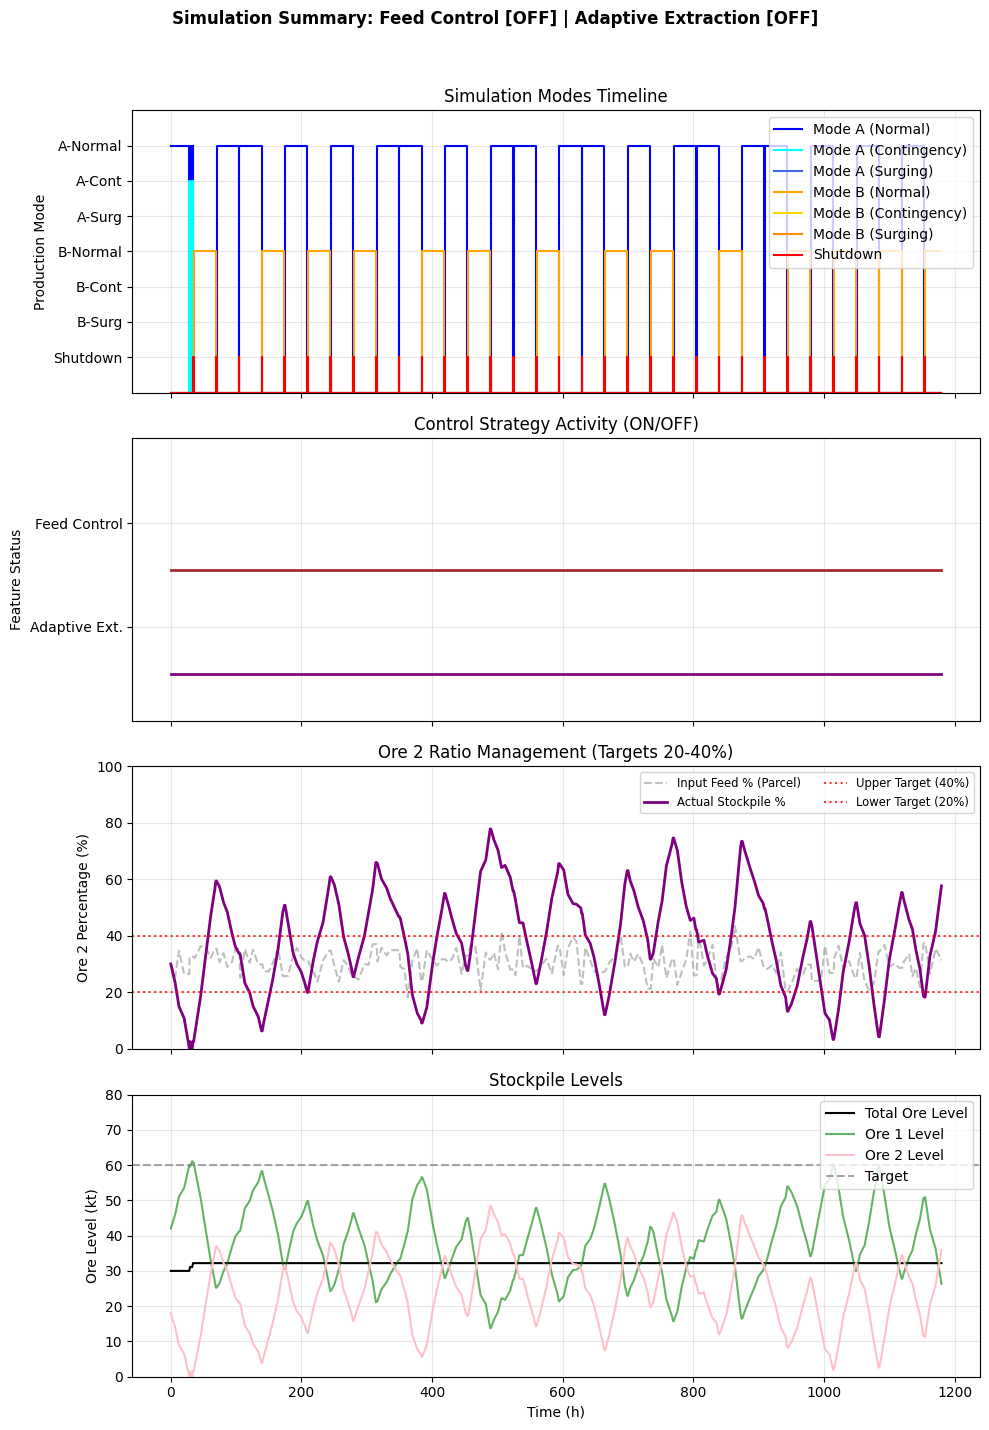

=== RUNNING SMART SYSTEM (CONTROLLERS ON) ===
Iteration 100: TNOW = 510.09
Iteration 200: TNOW = 1018.67
Smart Execution Time: 0.4437 seconds.
Smart Total Throughput: 6,082.70 t/day



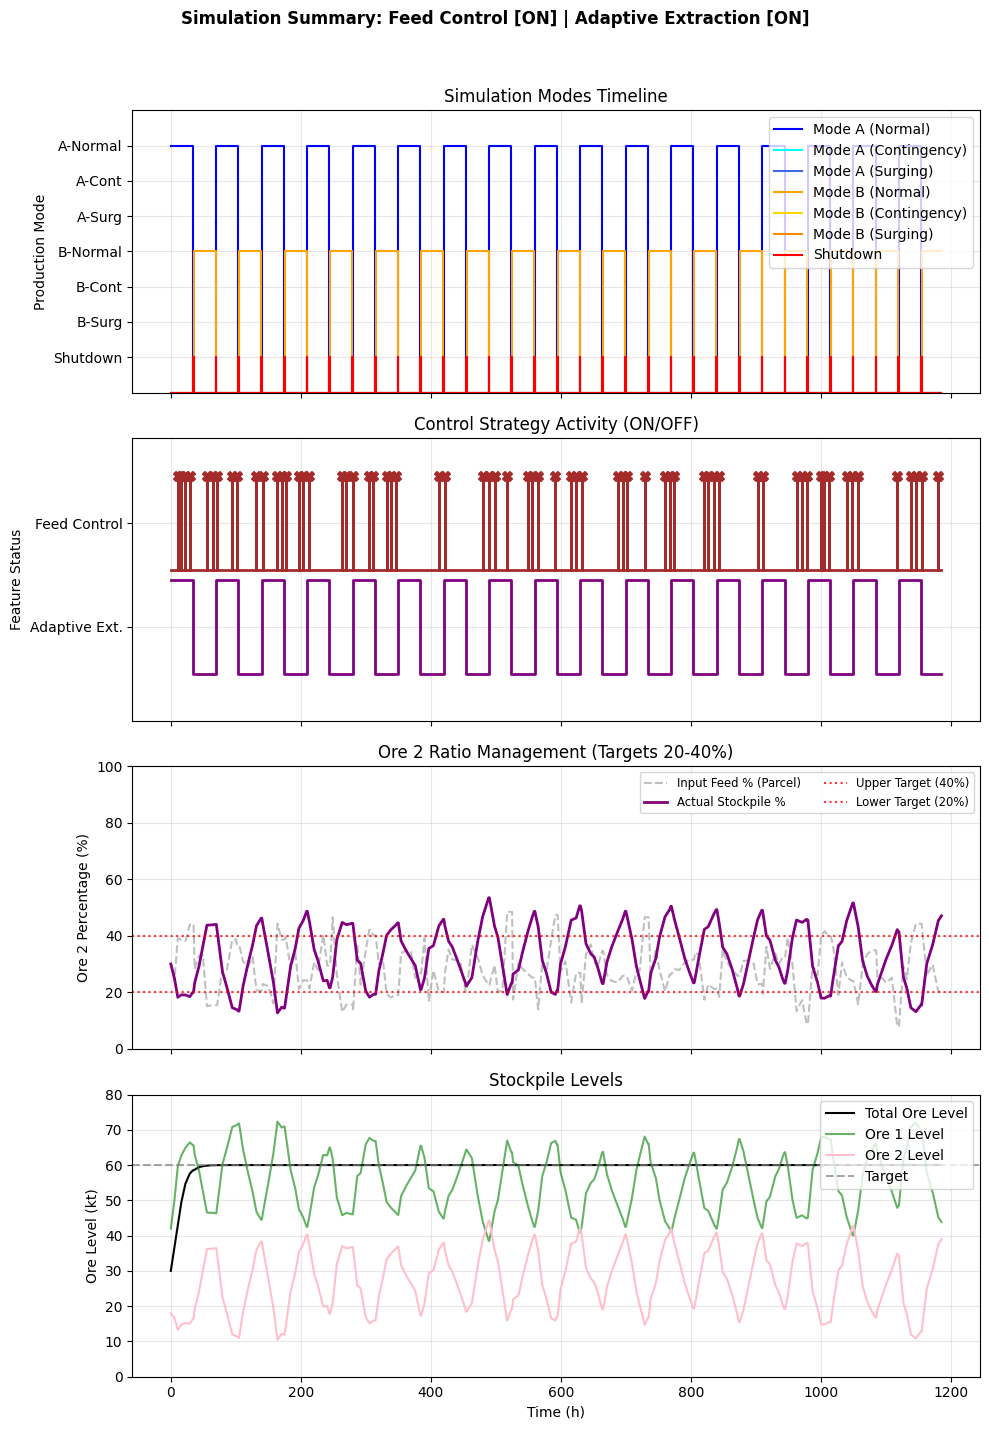

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
import time

from model.drs_model import DRSModel


@dataclass
class MiningParameters:
    parameter_OreToBeExtractedDuringWarmingPeriod: float = 600000.0
    parameter_TotalOreToBeExtracted: float = 6600000.0
    parameter_DurationOfProductionCampaigns: float = 34.0
    parameter_DurationOfShutdowns: float = 1.0
    parameter_ModeAOre1MillingRate: float = 3600.0
    parameter_ModeAOre2MillingRate: float = 2400.0
    parameter_ModeAContingencyOre1MillingRate: float = 3900.0
    parameter_ModeBOre1MillingRate: float = 4600.0
    parameter_ModeBOre2MillingRate: float = 800.0
    parameter_ModeBContingencyOre2MillingRate: float = 2500.0
    parameterVector_GeostatisticalModelParameters: tuple = (
        30000.0,
        50000.0,
        30.0,
        30.0,
        5.0,
        1.0,
    )
    controlVariable_CriticalOre2Level: float = 20400.0
    controlVariable_TargetOreStockLevel: float = 60000.0
    controlVariable_DurationOfContingencySegments: float = 1.0

    # Adaptive Extraction Limits
    parameter_MaxExtraction: float = 7200.0
    parameter_MinExtraction: float = 5000.0

    # Dynamic Toggles
    parameter_ExtractionGain: float = 0.0
    enable_feed_control: bool = False
    controlVariable_StockUpperLimit: float = 60000.0
    controlVariable_StockLowerLimit: float = 60000.0


def generate_arena_config():
    # 1. Total mill rates for normal modes
    total_mill_A = "(parameter_ModeAOre1MillingRate + parameter_ModeAOre2MillingRate)"
    total_mill_B = "(parameter_ModeBOre1MillingRate + parameter_ModeBOre2MillingRate)"

    # 2. Dynamic Adaptive Extraction variables (collapses to base rate when gain is 0)
    ext_A_norm = f"max(parameter_MinExtraction, min(parameter_MaxExtraction, {total_mill_A} + (controlVariable_TargetOreStockLevel - OreStock_Level) * parameter_ExtractionGain))"
    ext_A_cont = f"max(parameter_MinExtraction, min(parameter_MaxExtraction, parameter_ModeAContingencyOre1MillingRate + (controlVariable_TargetOreStockLevel - OreStock_Level) * parameter_ExtractionGain))"
    ext_B_norm = f"max(parameter_MinExtraction, min(parameter_MaxExtraction, {total_mill_B} + (controlVariable_TargetOreStockLevel - OreStock_Level) * parameter_ExtractionGain))"
    ext_B_cont = f"max(parameter_MinExtraction, min(parameter_MaxExtraction, parameter_ModeBContingencyOre2MillingRate + (controlVariable_TargetOreStockLevel - OreStock_Level) * parameter_ExtractionGain))"

    # 3. Your perfectly balanced configuration mapped to the dynamic variables
    config = {
        "confExString_TerminatingCondition": "(OreExtraction_Level >= parameter_TotalOreToBeExtracted)",
        "confExString_InitialRateConfigurationNumber": "1",
        "confExString_InitialLevelValue": ["0", "0", "30000", "42000", "18000"],
        "confExString_InitialTimerValue": ["0"] * 9,
        "confExString_InitialDiscretelyDynamicalNumericalVariableValue": [
            "40000",
            "30",
            "1",
        ],
        "confExString_InitialCategoricalVariableValue": [""],
        "confExString_LevelRate": [
            # Level 0 (Extraction)
            [
                ext_A_norm,
                ext_A_cont,
                "parameter_ModeAOre1MillingRate*100/(100-PercentageOfOre2InCurrentParcel)",
                ext_B_norm,
                ext_B_cont,
                "parameter_ModeBOre2MillingRate*100/PercentageOfOre2InCurrentParcel",
                "0",
            ],
            # Level 1 (Parcel Progress)
            [
                ext_A_norm,
                ext_A_cont,
                "parameter_ModeAOre1MillingRate*100/(100-PercentageOfOre2InCurrentParcel)",
                ext_B_norm,
                ext_B_cont,
                "parameter_ModeBOre2MillingRate*100/PercentageOfOre2InCurrentParcel",
                "0",
            ],
            # Level 2 (Total Stockpile Level)
            [
                f"{ext_A_norm} - {total_mill_A}",
                f"{ext_A_cont} - parameter_ModeAContingencyOre1MillingRate",
                f"(parameter_ModeAOre1MillingRate*100/(100-PercentageOfOre2InCurrentParcel)) - {total_mill_A}",
                f"{ext_B_norm} - {total_mill_B}",
                f"{ext_B_cont} - parameter_ModeBContingencyOre2MillingRate",
                f"(parameter_ModeBOre2MillingRate*100/PercentageOfOre2InCurrentParcel) - {total_mill_B}",
                "0",
            ],
            # Level 3 (Ore 1 Level)
            [
                f"{ext_A_norm}*(1-PercentageOfOre2InCurrentParcel/100)-parameter_ModeAOre1MillingRate",
                f"{ext_A_cont}*(1-PercentageOfOre2InCurrentParcel/100)-parameter_ModeAContingencyOre1MillingRate",
                "0",
                f"{ext_B_norm}*(100-PercentageOfOre2InCurrentParcel)/100 - parameter_ModeBOre1MillingRate",
                f"{ext_B_cont}*(100-PercentageOfOre2InCurrentParcel)/100",
                "parameter_ModeBOre2MillingRate*(100-PercentageOfOre2InCurrentParcel)/(PercentageOfOre2InCurrentParcel)-parameter_ModeBOre1MillingRate",
                "0",
            ],
            # Level 4 (Ore 2 Level)
            [
                f"{ext_A_norm}*(PercentageOfOre2InCurrentParcel/100)-parameter_ModeAOre2MillingRate",
                f"{ext_A_cont}*(PercentageOfOre2InCurrentParcel/100)",
                "parameter_ModeAOre1MillingRate*PercentageOfOre2InCurrentParcel/(100-PercentageOfOre2InCurrentParcel)-parameter_ModeAOre2MillingRate",
                f"{ext_B_norm}*PercentageOfOre2InCurrentParcel/100 - parameter_ModeBOre2MillingRate",
                f"{ext_B_cont}*PercentageOfOre2InCurrentParcel/100 - parameter_ModeBContingencyOre2MillingRate",
                "0",
                "0",
            ],
        ],
        "confExString_LowerLevelThreshold": [
            ["-999999"] * 7,
            ["-999999"] * 7,
            [
                "-999999",
                "-999999",
                "controlVariable_StockLowerLimit",
                "-999999",
                "-999999",
                "controlVariable_StockLowerLimit",
                "-999999",
            ],
            ["0", "0", "-999999", "0", "-999999", "-999999", "-999999"],
            ["0", "-999999", "-999999", "0", "0", "-999999", "-999999"],
        ],
        "confExString_UpperLevelThreshold": [
            [
                "(OreExtraction_Level < parameter_OreToBeExtractedDuringWarmingPeriod)*parameter_OreToBeExtractedDuringWarmingPeriod + (OreExtraction_Level >= parameter_OreToBeExtractedDuringWarmingPeriod)*parameter_TotalOreToBeExtracted"
            ]
            * 7,
            ["MassOfCurrentParcel"] * 6 + ["999999"],
            ["controlVariable_StockUpperLimit"] * 7,
            ["999999"] * 7,
            ["999999"] * 7,
        ],
        "confExString_LowerLevelResultantRateConfiguration": [
            ["0"] * 7,
            ["0"] * 7,
            ["0", "0", "1", "0", "0", "4", "0"],
            ["3", "3", "0", "5", "0", "0", "0"],
            ["2", "0", "0", "6", "6", "0", "0"],
        ],
        "confExString_UpperLevelResultantRateConfiguration": [
            ["1", "2", "3", "4", "5", "6", "0"],
            ["1", "2", "3", "4", "5", "6", "0"],
            ["0"] * 7,
            ["0"] * 7,
            ["0"] * 7,
        ],
        "confExString_LowerLevelAssignmentAddress": [
            ["0"] * 7,
            ["0"] * 7,
            ["0"] * 7,
            ["0", "0", "0", "3", "0", "0", "0"],
            ["3", "0", "0", "0", "0", "0", "0"],
        ],
        "confExString_UpperLevelAssignmentAddress": [
            [
                "0 + 1*(OreExtraction_Level == parameter_OreToBeExtractedDuringWarmingPeriod)"
            ]
            * 6
            + ["0"],
            [
                "(NextParcelIsNewFacies==1)*(parameterVector_GeostatisticalModelParameters(5)<>0)*4 + (NextParcelIsNewFacies==1)*(parameterVector_GeostatisticalModelParameters(5)==0)*5 + (NextParcelIsNewFacies==0)*6"
            ]
            * 6
            + ["0"],
            ["0"] * 7,
            ["0"] * 7,
            ["0"] * 7,
        ],
        "confExString_TimerRate": [
            ["1"] * 7,
            ["0", "1", "0", "0", "1", "0", "0"],
            ["1", "0", "0", "0", "0", "0", "0"],
            ["0", "1", "0", "0", "0", "0", "0"],
            ["0", "0", "1", "0", "0", "0", "0"],
            ["0", "0", "0", "1", "0", "0", "0"],
            ["0", "0", "0", "0", "1", "0", "0"],
            ["0", "0", "0", "0", "0", "1", "0"],
            ["0", "0", "0", "0", "0", "0", "1"],
        ],
        "confExString_LowerTimerThreshold": [["-999999"] * 7 for _ in range(9)],
        "confExString_UpperTimerThreshold": [
            ["parameter_DurationOfProductionCampaigns"] * 6
            + ["parameter_DurationOfShutdowns"],
            [
                "999999",
                "controlVariable_DurationOfContingencySegments",
                "999999",
                "999999",
                "controlVariable_DurationOfContingencySegments",
                "999999",
                "999999",
            ],
            ["999999"] * 7,
            ["999999"] * 7,
            ["999999"] * 7,
            ["999999"] * 7,
            ["999999"] * 7,
            ["999999"] * 7,
            ["999999"] * 7,
        ],
        "confExString_LowerTimerResultantRateConfiguration": [
            ["0"] * 7 for _ in range(9)
        ],
        "confExString_UpperTimerResultantRateConfiguration": [
            [
                "7",
                "7",
                "7",
                "7",
                "7",
                "7",
                "(Ore2Stock_Level>controlVariable_CriticalOre2Level)*(OreStock_Level<=controlVariable_StockUpperLimit)*1+(Ore2Stock_Level>controlVariable_CriticalOre2Level)*(OreStock_Level>controlVariable_StockUpperLimit)*3+(Ore2Stock_Level<=controlVariable_CriticalOre2Level)*(OreStock_Level<=controlVariable_StockUpperLimit)*4+(Ore2Stock_Level<=controlVariable_CriticalOre2Level)*(OreStock_Level>controlVariable_StockUpperLimit)*6",
            ],
            ["0", "1", "0", "0", "4", "0", "0"],
            ["0"] * 7,
            ["0"] * 7,
            ["0"] * 7,
            ["0"] * 7,
            ["0"] * 7,
            ["0"] * 7,
            ["0"] * 7,
        ],
        "confExString_UpperTimerAssignmentAddress": [
            ["2"] * 7,
            ["0"] * 7,
            ["0"] * 7,
            ["0"] * 7,
            ["0"] * 7,
            ["0"] * 7,
            ["0"] * 7,
            ["0"] * 7,
            ["0"] * 7,
        ],
        "confExString_LowerTimerAssignmentAddress": [["0"] * 7 for _ in range(9)],
        "confExString_AssignmentSequence": [
            ["T003:0", "T004:0", "T005:0", "T006:0", "T007:0", "T008:0", "T009:0"],
            ["T001:0", "", "", "", "", "", ""],
            ["T002:0", "", "", "", "", "", ""],
            # Added E001:1 so the Feed Controller actually gets triggered when drawing parcels
            [
                "L002:0",
                "N001:UNIF(parameterVector_GeostatisticalModelParameters(1),parameterVector_GeostatisticalModelParameters(2))",
                "N002:MX(NORM(parameterVector_GeostatisticalModelParameters(4),parameterVector_GeostatisticalModelParameters(5)),0)",
                "N003:(UNIF(0,1)<= parameterVector_GeostatisticalModelParameters(3))",
                "E001:1",
                "",
                "",
            ],
            [
                "L002:0",
                "N001:UNIF(parameterVector_GeostatisticalModelParameters(1),parameterVector_GeostatisticalModelParameters(2))",
                "N002:parameterVector_GeostatisticalModelParameters(4)",
                "N003:(UNIF(0,1)<= parameterVector_GeostatisticalModelParameters(3))",
                "E001:1",
                "",
                "",
            ],
            [
                "L002:0",
                "N001:UNIF(parameterVector_GeostatisticalModelParameters(1),parameterVector_GeostatisticalModelParameters(2))",
                "N002:MX(PercentageOfOre2InCurrentParcel + parameterVector_GeostatisticalModelParameters(6)*UNIF(-1,1),0)",
                "N003:(UNIF(0,1)<= parameterVector_GeostatisticalModelParameters(3))",
                "E001:1",
                "",
                "",
            ],
        ],
    }
    return config


# ==========================================
# RUN 1: BASELINE (Controllers OFF)
# ==========================================
print("=== RUNNING BASELINE (CONTROLLERS OFF) ===")
params_baseline = MiningParameters()
params_baseline.parameter_ExtractionGain = 0.0
params_baseline.enable_feed_control = False
params_baseline.controlVariable_StockUpperLimit = 60000.0  # Hysteresis OFF
params_baseline.controlVariable_StockLowerLimit = 60000.0

baseline_model = DRSModel(parameters=params_baseline)
baseline_model.load_configuration(generate_arena_config())

start_time = time.time()
baseline_model.run()
print(f"Baseline Execution Time: {time.time() - start_time:.4f} seconds.")

stats_base = baseline_model.calculate_statistics()
print(f"Baseline Total Throughput: {stats_base.Throughput:,.2f} t/day\n")
baseline_model.plot_results()


# ==========================================
# RUN 2: SMART (Controllers ON)
# ==========================================
print("=== RUNNING SMART SYSTEM (CONTROLLERS ON) ===")
params_smart = MiningParameters()
params_smart.parameter_ExtractionGain = 0.08  # Adaptive Extraction ON
params_smart.enable_feed_control = True  # Feed Control ON
params_smart.controlVariable_StockUpperLimit = 65000.0  # +5k Upper Deadband
params_smart.controlVariable_StockLowerLimit = 50000.0  # -10k Lower Deadband

smart_model = DRSModel(parameters=params_smart)
smart_model.load_configuration(generate_arena_config())

start_time = time.time()
smart_model.run()
print(f"Smart Execution Time: {time.time() - start_time:.4f} seconds.")

stats_smart = smart_model.calculate_statistics()
print(f"Smart Total Throughput: {stats_smart.Throughput:,.2f} t/day\n")
smart_model.plot_results()